# RQ2 Notebook


In [ ]:
"""
RQ2 - Lineage Depth and Derivation Statistics

- Goal: Analyze the depth of model lineages and the number of derivatives from base models.
- Method: Use BFS from base models to compute depth and descendant counts.

Outputs:
  - rq2_base_model_depths.csv        : depth + descendant stats per top-N base model
  - rq2_depth_distribution_global.csv: GLOBAL depth counts across ALL base models
  - rq2_depth_distribution_top100.csv: depth counts from top 100 only (for comparison)
  - rq2_summary.txt
"""

import pandas as pd
import networkx as nx
from collections import defaultdict

EDGES_FILE = "edges.csv"
NODES_FILE = "all_text_generation_models.csv"
TOP_N_BASE  = 100    # for per-model detailed stats only

print("Loading data...")
edges = pd.read_csv(EDGES_FILE)
nodes = pd.read_csv(NODES_FILE)

if "Id" in nodes.columns and "model_id" not in nodes.columns:
    nodes = nodes.rename(columns={"Id": "model_id"})

G = nx.from_pandas_edgelist(
    edges, source="Source", target="Target",
    edge_attr=["Transformation", "Confidence"],
    create_using=nx.DiGraph()
)

in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
nodes["downloads"] = pd.to_numeric(nodes["downloads"], errors="coerce").fillna(0)

# Identify base models: in-degree=0 and out-degree>0 (roots of derivation trees)
base_models = [n for n, d in in_deg.items() if d == 0 and out_deg.get(n, 0) > 0]
print(f"Base models (in-degree=0, out-degree>0): {len(base_models):,}")

all_base_models = [n for n, d in in_deg.items() if d == 0]
print(f"All nodes with in-degree=0 (incl. isolated): {len(all_base_models):,}")

# Connected components stats (for context on graph structure)
wcc = list(nx.weakly_connected_components(G))
print(f"\nWeakly connected components: {len(wcc):,}")
print(f"Largest component:           {max(len(c) for c in wcc):,} nodes")
print(f"Singleton components:        {sum(1 for c in wcc if len(c)==1):,}")

# Global BFS from all base models to get a complete depth distribution
print(f"\nRunning GLOBAL BFS from all {len(base_models):,} base models...")
print("(This may take a few minutes for large graphs)")

global_depth_counts = defaultdict(int)   # depth → count of nodes at that depth
# Track minimum depth per node across all BFS trees to avoid double-counting
global_node_min_depth = {}

for bm in base_models:
    try:
        lengths = nx.single_source_shortest_path_length(G, bm)
    except Exception:
        continue
    for node, depth in lengths.items():
        if node == bm:
            continue
        if node not in global_node_min_depth or depth < global_node_min_depth[node]:
            global_node_min_depth[node] = depth

# Build global distribution from deduplicated min-depths
for node, depth in global_node_min_depth.items():
    global_depth_counts[depth] += 1

global_dist_df = pd.DataFrame([
    {"depth": d, "model_count": c}
    for d, c in sorted(global_depth_counts.items())
])
global_dist_df["cumulative_pct"] = (
    global_dist_df["model_count"].cumsum() /
    global_dist_df["model_count"].sum() * 100
).round(1)

print(f"\n=== GLOBAL DEPTH DISTRIBUTION (all base models, deduplicated) ===")
print(f"Total nodes assigned a depth: {sum(global_depth_counts.values()):,}")
print(global_dist_df.to_string(index=False))
global_dist_df.to_csv("rq2_depth_distribution_global.csv", index=False)
print("Saved rq2_depth_distribution_global.csv")

# Per-model BFS for top-N base models by direct derivatives (for detailed stats and comparison)
top_base = sorted(base_models, key=lambda n: out_deg.get(n, 0), reverse=True)[:TOP_N_BASE]
print(f"\nRunning per-model BFS for top {TOP_N_BASE} base models (detailed stats)...")

depth_rows = []
top100_depth_counts = defaultdict(int)

for bm in top_base:
    try:
        lengths = nx.single_source_shortest_path_length(G, bm)
    except Exception:
        continue

    descendants = len(lengths) - 1
    if descendants == 0:
        continue

    max_depth = max(lengths.values())
    avg_depth = sum(v for k, v in lengths.items() if k != bm) / descendants
    depth_dist = defaultdict(int)

    for node, depth in lengths.items():
        if node != bm:
            depth_dist[depth] += 1
            top100_depth_counts[depth] += 1

    meta       = nodes[nodes["model_id"] == bm]
    downloads  = int(meta["downloads"].values[0])  if len(meta) > 0 else 0
    creator    = meta["creator"].values[0]          if len(meta) > 0 else "unknown"
    created_at = meta["created_at"].values[0]       if len(meta) > 0 else None

    mid = bm.lower()
    if   "llama"     in mid: family = "LLaMA"
    elif "qwen"      in mid: family = "Qwen"
    elif "mistral"   in mid: family = "Mistral"
    elif "gpt"       in mid: family = "GPT"
    elif "deepseek"  in mid: family = "DeepSeek"
    elif "gemma"     in mid: family = "Gemma"
    elif "phi"       in mid: family = "Phi"
    else:                     family = "Other"

    depth_rows.append({
        "model_id":              bm,
        "creator":               creator,
        "family":                family,
        "downloads":             downloads,
        "created_at":            created_at,
        "direct_derivatives":    out_deg.get(bm, 0),
        "total_descendants":     descendants,
        "max_depth":             max_depth,
        "avg_depth":             round(avg_depth, 2),
        "depth_1_count":         depth_dist.get(1, 0),
        "depth_2_count":         depth_dist.get(2, 0),
        "depth_3_count":         depth_dist.get(3, 0),
        "depth_4plus_count":     sum(v for k, v in depth_dist.items() if k >= 4),
    })

depth_df = pd.DataFrame(depth_rows).sort_values("max_depth", ascending=False)
depth_df.to_csv("rq2_base_model_depths.csv", index=False)
print(f"Saved rq2_base_model_depths.csv ({len(depth_df)} rows)")

# Also save top-100 depth distribution for direct comparison with global
top100_dist_df = pd.DataFrame([
    {"depth": d, "model_count": c}
    for d, c in sorted(top100_depth_counts.items())
])
top100_dist_df["cumulative_pct"] = (
    top100_dist_df["model_count"].cumsum() /
    top100_dist_df["model_count"].sum() * 100
).round(1)
top100_dist_df.to_csv("rq2_depth_distribution_top100.csv", index=False)
print("Saved rq2_depth_distribution_top100.csv")

# Display top-20 deepest lineages
print("\n=== TOP 20 DEEPEST LINEAGES ===")
cols = ["model_id","family","direct_derivatives","total_descendants","max_depth","avg_depth"]
print(depth_df[cols].head(20).to_string(index=False))

# Compare global vs top-100 depth distributions
print("\n=== GLOBAL vs TOP-100 DEPTH DISTRIBUTION COMPARISON ===")
comparison = global_dist_df.rename(columns={"model_count": "global_count", "cumulative_pct": "global_cumulative_pct"}).merge(
    top100_dist_df.rename(columns={"model_count": "top100_count", "cumulative_pct": "top100_cumulative_pct"}),
    on="depth", how="outer"
).sort_values("depth").fillna(0)
print(comparison.to_string(index=False))
print("\nNOTE: global_count counts each node once at its MINIMUM depth from any root.")
print("      top100_count may double-count nodes reachable from multiple top-100 bases.")

# Family-level depth stats
print("\n=== DEPTH STATS BY MODEL FAMILY ===")
family_stats = depth_df.groupby("family").agg(
    base_model_count  = ("model_id",           "count"),
    avg_max_depth     = ("max_depth",           "mean"),
    max_max_depth     = ("max_depth",           "max"),
    avg_descendants   = ("total_descendants",   "mean"),
    total_descendants = ("total_descendants",   "sum"),
).round(2).sort_values("max_max_depth", ascending=False)
print(family_stats)

# Summary statistics for report
total_in_graph = global_dist_df["model_count"].sum()
summary = f"""
RQ2 SUMMARY STATISTICS (Fixed — Global Depth Distribution)

Total base models (in-deg=0, out-deg>0):   {len(base_models):,}
Weakly connected components:               {len(wcc):,}
Largest component:                         {max(len(c) for c in wcc):,} nodes

GLOBAL depth distribution (all {len(base_models):,} base models, deduplicated):
  Total nodes assigned a depth:  {total_in_graph:,}
  Max depth in graph:            {global_dist_df['depth'].max()}
  AVG depth (weighted):           {(global_dist_df['depth'] * global_dist_df['model_count']).sum() / total_in_graph:.2f}
  Nodes at depth 1:              {int(global_dist_df[global_dist_df['depth']==1]['model_count'].sum()):,}
  Nodes at depth 2:              {int(global_dist_df[global_dist_df['depth']==2]['model_count'].sum()):,}
  Nodes at depth 3+:             {int(global_dist_df[global_dist_df['depth']>=3]['model_count'].sum()):,}
  % at depth 1:                  {global_dist_df[global_dist_df['depth']==1]['model_count'].sum()/max(total_in_graph,1)*100:.1f}%
  % at depth 2:                  {global_dist_df[global_dist_df['depth']==2]['model_count'].sum()/max(total_in_graph,1)*100:.1f}%
  % at depth 3+:                 {global_dist_df[global_dist_df['depth']>=3]['model_count'].sum()/max(total_in_graph,1)*100:.1f}%

Global depth distribution table:
{global_dist_df.to_string(index=False)}

Per-model stats (top {TOP_N_BASE} base models by direct derivatives):
  Max depth overall:    {depth_df['max_depth'].max()}
  Avg max depth:        {depth_df['max_depth'].mean():.2f}
  Median max depth:     {depth_df['max_depth'].median():.1f}

Top 10 deepest lineages:
{depth_df[['model_id','family','max_depth','total_descendants']].head(10).to_string(index=False)}

Family-level depth stats:
{family_stats.to_string()}
"""
with open("rq2_summary.txt", "w") as f:
    f.write(summary)
print(summary)
print("Saved rq2_summary.txt")

Loading data...
Base models (in-degree=0, out-degree>0): 30,170
All nodes with in-degree=0 (incl. isolated): 30,170

Weakly connected components: 27,044
Largest component:           70,437 nodes
Singleton components:        0

Running GLOBAL BFS from all 30,170 base models...
(This may take a few minutes for large graphs)

=== GLOBAL DEPTH DISTRIBUTION (all base models, deduplicated) ===
Total nodes assigned a depth: 164,197
 depth  model_count  cumulative_pct
     1       100448            61.2
     2        46151            89.3
     3        13957            97.8
     4         2599            99.4
     5          543            99.7
     6          180            99.8
     7          109            99.9
     8           49            99.9
     9           35            99.9
    10           26            99.9
    11           20           100.0
    12           26           100.0
    13           14           100.0
    14            7           100.0
    15            7           1

## RQ2 Visualizations
Only the visualizations relevant to this notebook are kept.

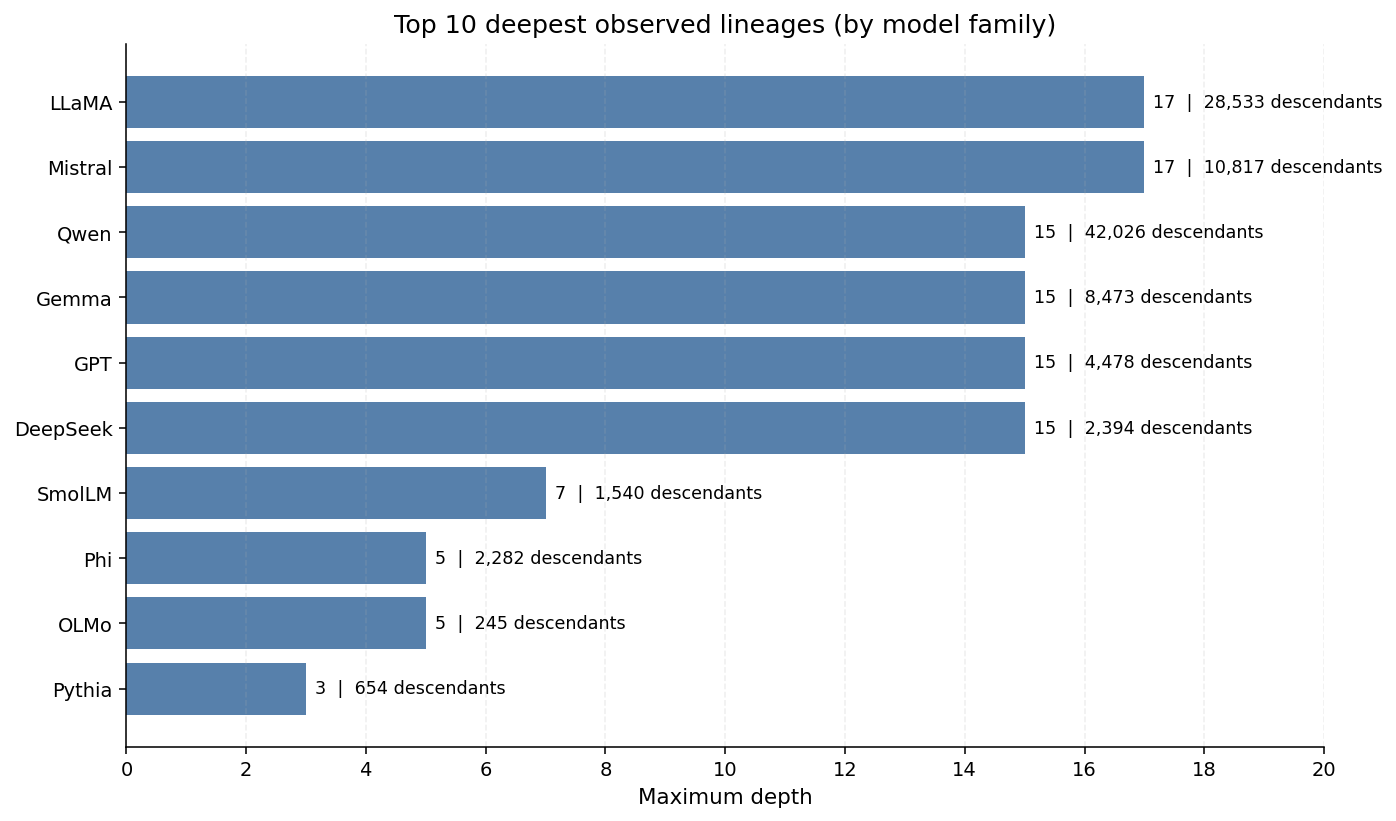

Saved RQ2 PDFs to: rq2_figures


In [2]:

# RQ2 visualizations (trimmed from visualization.py)
import os
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import networkx as nx
from matplotlib.ticker import MaxNLocator

OUT = 'rq2_figures'
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.linestyle': '--',
})

C1 = '#4E79A7'

RQ2_GLOBAL = 'rq2_depth_distribution_global.csv'
RQ2_TOP100 = 'rq2_depth_distribution_top100.csv'
RQ2_BASES = 'rq2_base_model_depths.csv'
EDGES_FILE = 'edges.csv'


def save_pdf(name: str):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, name), bbox_inches='tight')
    plt.show()
    plt.close()


def shorten(model_id: str) -> str:
    s = str(model_id)
    return s.split('/')[-1]

def rq2_deepest_lineages_by_family():
    df = pd.read_csv(RQ2_BASES).copy()
    edges = pd.read_csv(EDGES_FILE)
    edges.columns = [c.lower() for c in edges.columns]
    parent_map = dict(zip(edges['target'].astype(str), edges['source'].astype(str)))

    def get_root(model_id: str) -> str:
        visited = set()
        node = str(model_id)
        while node in parent_map:
            if node in visited:
                break
            visited.add(node)
            node = parent_map[node]
        return node

    FAMILY_RULES = [
        ('LLaMA', ['llama', 'meta-llama', 'l3-', 'l3.1-', 'l3.2-', 'stheno', 'euryale', 'hanami', 'vicuna', 'anubis', 'wizardlmteam']),
        ('Mistral', ['mistral', 'mixtral', 'm7-', 'mammoth2']),
        ('DeepSeek', ['deepseek']),
        ('Qwen', ['qwen']),
        ('Gemma', ['gemma']),
        ('GPT', ['gpt2', 'gpt-', 'openai']),
        ('Nemotron', ['nemotron']),
        ('Falcon', ['falcon']),
        ('Bloom', ['bloom']),
        ('Phi', ['phi-', '/phi']),
        ('Pythia', ['pythia']),
        ('SmolLM', ['smollm']),
        ('OLMo', ['olmo']),
    ]

    def model_to_family(model_id: str) -> str:
        s = str(model_id).lower()
        for family, keywords in FAMILY_RULES:
            if any(kw in s for kw in keywords):
                return family
        return 'Other'

    df['root'] = df['model_id'].map(get_root)
    df['family'] = df['root'].map(model_to_family)
    agg = df.groupby('family').agg(
        max_depth=('max_depth', 'max'),
        total_descendants=('total_descendants', 'sum')
    ).reset_index()
    agg = agg[agg['family'] != 'Other']
    agg = agg.sort_values(['max_depth', 'total_descendants'], ascending=[False, False]).head(10)
    agg = agg.sort_values(['max_depth', 'total_descendants'], ascending=[True, True])

    fig, ax = plt.subplots(figsize=(10.2, 6.0))
    bars = ax.barh(agg['family'], agg['max_depth'], color=C1, alpha=0.95)
    ax.set_title('Top 10 deepest observed lineages (by model family)')
    ax.set_xlabel('Maximum depth')
    ax.set_ylabel('')
    ax.set_xlim(0, int(agg['max_depth'].max()) + 3)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.grid(True, alpha=0.2)
    ax.yaxis.grid(False)

    for bar, total_desc in zip(bars, agg['total_descendants']):
        ax.text(bar.get_width() + 0.15,
                bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width())}  |  {int(total_desc):,} descendants',
                va='center', ha='left', fontsize=9)

    save_pdf('rq2_deepest_lineages_by_family.pdf')


rq2_deepest_lineages_by_family()
print(f'Saved RQ2 PDFs to: {OUT}')
